# Market Basket Analysis (FP-Growth)

Step-by-step notebook in procedural format.

## Context

This notebook assumes `df_merged` already exists with: `reference`, `article`, `cluster`.

## Step 1 - Imports and Paths

In [14]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Resolve project root dynamically (works whether cwd is project root or notebooks/)
cwd = Path.cwd().resolve()
candidates = [
    cwd,
    cwd.parent,
    Path(r"C:/Users/H-Info/OneDrive/Desktop/graduation_project/2425produits analysis"),
]
base_path = next((c for c in candidates if (c / "data").exists()), candidates[-1])

fig_dir = base_path / "outputs" / "figures"
model_dir = base_path / "outputs" / "models"
fig_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
print("Using base_path:", base_path)

Using base_path: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis


## Step 2 - Validate `df_merged`

In [15]:
required_cols = {"reference", "article", "cluster", "year"}

merged_path = base_path / "data" / "merged_data.csv"
cleaned_path = base_path / "data" / "processed" / "cleaned_data.csv"
cluster_path = base_path / "data" / "processed" / "client_cluster.csv"

if merged_path.exists():
    df_merged = pd.read_csv(merged_path)
    source_used = merged_path
elif cleaned_path.exists() and cluster_path.exists():
    sales_df = pd.read_csv(cleaned_path)
    clusters_df = pd.read_csv(cluster_path)
    clusters_df = clusters_df.rename(columns={"Code_client": "code_client", "Cluster": "cluster"})
    df_merged = sales_df.merge(clusters_df[["code_client", "cluster"]], on="code_client", how="left")
    source_used = f"merge({cleaned_path.name} + {cluster_path.name})"
else:
    raise FileNotFoundError(
        f"Could not find input files. Checked: {merged_path}, {cleaned_path}, {cluster_path}"
    )

missing = required_cols - set(df_merged.columns)
if missing:
    raise ValueError(f"Missing required columns in df_merged: {missing}")

print("Loaded source:", source_used)
print("Shape before dropna:", df_merged.shape)
print("Nulls in cluster:", int(df_merged["cluster"].isna().sum()))

df_merged = df_merged.dropna(subset=["cluster", "year", "reference"]).copy()
basket_keys = ["code_client", "year", "reference"]
print("Shape after dropna(cluster/year/reference):", df_merged.shape)
print("Basket keys:", basket_keys)
print("Unique baskets:", df_merged.groupby(basket_keys).ngroups)

Loaded source: merge(cleaned_data.csv + client_cluster.csv)
Shape before dropna: (506009, 18)
Nulls in cluster: 106214
Shape after dropna(cluster/year/reference): (399795, 18)
Basket keys: ['code_client', 'year', 'reference']
Unique baskets: 34813


In [16]:
df_merged 



,reference,date,code,article,client,quantite,prix_de_vente,montant,pmp_stock,taux_mb,cbm,code_client,year,month,day,day_name,month_name,cluster
4,A0060,2024-01-01,2,ELIO 2 L,BOROUMI,75.0,1430.00,107250.00,1410.00,1.42,0.750,BO000021,2024,1,1,Monday,January,2.0
5,A0060,2024-01-01,3,ELIO 5 L,BOROUMI,168.0,600.00,100800.00,585.00,2.56,1.680,BO000021,2024,1,1,Monday,January,2.0
6,A0088,2024-01-01,1203,MHAMSSA SIM,AMMAR BOUDERSSA,1.0,1100.00,1100.00,1030.00,6.80,0.010,AM000012,2024,1,1,Monday,January,2.0
8,A0061,2024-01-01,118,SUCRE 1 KG 10 KG CEVI,/AHMED CHOUIH,2.0,880.02,1760.04,702.72,25.23,0.020,AH000004,2024,1,1,Monday,January,2.0
9,A0061,2024-01-01,2062,MAIS 25 KG VRAQ,/AHMED CHOUIH,5.0,220.00,1100.00,190.00,15.79,0.050,AH000004,2024,1,1,Monday,January,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505996,L2822,2025-12-31,2094,KOJAK KICHITA,NADIR SHOP EL BORDJ,1.0,800.01,800.01,730.00,9.59,0.010,NA000007,2025,12,31,Wednesday,December,2.0
505997,L2822,2025-12-31,110,OPTILA STIC 5DA,NADIR SHOP EL BORDJ,4.0,450.00,1800.00,433.66,3.77,0.040,NA000007,2025,12,31,Wednesday,December,2.0
505998,L2822,2025-12-31,2011,LENTILLE ORANGE VRAC,NADIR SHOP EL BORDJ,9.6,200.00,1920.00,186.99,6.96,0.096,NA000007,2025,12,31,Wednesday,December,2.0
505999,L2822,2025-12-31,2239,QUIKLY CHOCO,NADIR SHOP EL BORDJ,6.0,370.00,2220.00,345.05,7.23,0.060,NA000007,2025,12,31,Wednesday,December,2.0


In [17]:
# Check if the same reference appears in multiple years or clients
ref_check = (
    df_merged.groupby("reference")
    .agg(
        nb_years=("year", "nunique"),
        nb_clients=("code_client", "nunique"),
        nb_rows=("article", "size")
    )
    .reset_index()
)

problem_refs = ref_check[
    (ref_check["nb_years"] > 1) |
    (ref_check["nb_clients"] > 1)
]

print("Total references:", df_merged["reference"].nunique())
print("Problem references:", len(problem_refs))
print("Percentage problematic:", len(problem_refs) / df_merged["reference"].nunique() * 100)

problem_refs.head(20)

Total references: 25865
Problem references: 8948
Percentage problematic: 34.595012565242605


,reference,nb_years,nb_clients,nb_rows
3,A0003,2,2,7
5,A0005,2,2,53
6,A0006,2,2,27
7,A0007,2,2,18
8,A0008,2,2,30
9,A0009,2,2,20
10,A0010,2,2,25
12,A0012,2,2,24
15,A0015,2,2,27
16,A0016,2,2,12


## Step 3 - Global FP-Growth

In [18]:
baskets_global = (
    df_merged.groupby(basket_keys)["article"]
    .apply(lambda x: [str(v).strip() for v in x.dropna().astype(str) if str(v).strip()])
    .tolist()
)
baskets_global = [b for b in baskets_global if b]

te = TransactionEncoder()
encoded_global = te.fit(baskets_global).transform(baskets_global)
df_encoded_global = pd.DataFrame(encoded_global, columns=te.columns_)

itemsets_global = fpgrowth(df_encoded_global, min_support=0.01, use_colnames=True)
rules_global = association_rules(itemsets_global, metric="lift", min_threshold=1.0)
rules_global = rules_global[(rules_global["confidence"] >= 0.3) & (rules_global["lift"] >= 1.2)].sort_values("lift", ascending=False)

print("Global baskets:", len(baskets_global))
print("Global itemsets:", len(itemsets_global))
print("Global rules:", len(rules_global))
rules_global[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)

Global baskets: 34813
Global itemsets: 2825
Global rules: 5522


,antecedents,consequents,support,confidence,lift
14668,frozenset({MOUCHOIRE 80 F 40PS}),frozenset({SACHET BLANC 5 KG}),0.011921,0.528662,24.971947
14669,frozenset({SACHET BLANC 5 KG}),frozenset({MOUCHOIRE 80 F 40PS}),0.011921,0.563094,24.971947
13702,"frozenset({CHREA 1 L, SACHET NOIRE 5 KG})","frozenset({SACHET SUPER 1 KG, CHREA 2 L})",0.011576,0.537333,17.320542
13703,"frozenset({SACHET SUPER 1 KG, CHREA 2 L})","frozenset({CHREA 1 L, SACHET NOIRE 5 KG})",0.011576,0.373148,17.320542
9225,"frozenset({PATE AMORE 2 KG, SOMAM JNINA})","frozenset({SOMAM FLAN, CACHIR AMOURE / ASSIL 2...",0.010025,0.465333,16.769823
9228,"frozenset({SOMAM FLAN, CACHIR AMOURE / ASSIL 2...","frozenset({PATE AMORE 2 KG, SOMAM JNINA})",0.010025,0.361284,16.769823
13700,"frozenset({CHREA 1 L, SACHET SUPER 1 KG})","frozenset({CHREA 2 L, SACHET NOIRE 5 KG})",0.011576,0.546811,16.368139
13705,"frozenset({CHREA 2 L, SACHET NOIRE 5 KG})","frozenset({CHREA 1 L, SACHET SUPER 1 KG})",0.011576,0.346518,16.368139
9229,"frozenset({SOMAM JNINA, CACHIR AMOURE / ASSIL ...","frozenset({PATE AMORE 2 KG, SOMAM FLAN})",0.010025,0.300603,16.275101
9224,"frozenset({PATE AMORE 2 KG, SOMAM FLAN})","frozenset({SOMAM JNINA, CACHIR AMOURE / ASSIL ...",0.010025,0.542768,16.275101


## Step 4 - Save Global Rules

In [19]:
rules_global_save = rules_global.copy()
rules_global_save["antecedents"] = rules_global_save["antecedents"].apply(lambda s: ", ".join(sorted(map(str, s))))
rules_global_save["consequents"] = rules_global_save["consequents"].apply(lambda s: ", ".join(sorted(map(str, s))))

global_rules_path = model_dir / "association_rules_global.csv"
rules_global_save.to_csv(global_rules_path, index=False, encoding="utf-8-sig")
print("Saved:", global_rules_path)
print("Rows:", len(rules_global_save))

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\models\association_rules_global.csv
Rows: 5522


## Step 5 - FP-Growth Per Cluster

In [20]:
cluster_ids = sorted(df_merged["cluster"].dropna().unique().tolist())
print("Cluster ids:", cluster_ids)

segment_names = {
    0: "Loyal Customers",
    1: "Lost Customers",
    2: "Best Customers",
    3: "At Risk Customers",
}

def cluster_label(cluster_id):
    return segment_names.get(int(cluster_id), f"Cluster {cluster_id}")

cluster_results = {}
summary_rows = []

for cluster_id in cluster_ids:
    df_c = df_merged[df_merged["cluster"] == cluster_id].copy()
    baskets_c = (
        df_c.groupby(basket_keys)["article"]
        .apply(lambda x: [str(v).strip() for v in x.dropna().astype(str) if str(v).strip()])
        .tolist()
    )
    baskets_c = [b for b in baskets_c if b]

    te_c = TransactionEncoder()
    encoded_c = te_c.fit(baskets_c).transform(baskets_c)
    df_encoded_c = pd.DataFrame(encoded_c, columns=te_c.columns_)

    itemsets_c = fpgrowth(df_encoded_c, min_support=0.01, use_colnames=True)
    rules_c = association_rules(itemsets_c, metric="lift", min_threshold=1.0)
    rules_c = rules_c[(rules_c["confidence"] >= 0.3) & (rules_c["lift"] >= 1.2)].sort_values("lift", ascending=False)

    print(f"Cluster {cluster_id} | baskets={len(baskets_c)} | itemsets={len(itemsets_c)} | rules={len(rules_c)}")
    display(rules_c[["antecedents", "consequents", "support", "confidence", "lift"]].head(10))

    rules_save = rules_c.copy()
    if not rules_save.empty:
        rules_save["antecedents"] = rules_save["antecedents"].apply(lambda s: ", ".join(sorted(map(str, s))))
        rules_save["consequents"] = rules_save["consequents"].apply(lambda s: ", ".join(sorted(map(str, s))))
    rules_save.to_csv(model_dir / f"association_rules_cluster_{cluster_id}.csv", index=False, encoding="utf-8-sig")

    cluster_results[cluster_id] = {"baskets": baskets_c, "itemsets": itemsets_c, "rules": rules_c}
    summary_rows.append({
        "cluster": cluster_id,
        "nb_baskets": len(baskets_c),
        "nb_rules": len(rules_c),
        "avg_lift": float(rules_c["lift"].mean()) if not rules_c.empty else 0.0,
        "avg_confidence": float(rules_c["confidence"].mean()) if not rules_c.empty else 0.0,
        "avg_support": float(rules_c["support"].mean()) if not rules_c.empty else 0.0,
    })

Cluster ids: [0.0, 1.0, 2.0, 3.0]
Cluster 0.0 | baskets=7497 | itemsets=462 | rules=302


,antecedents,consequents,support,confidence,lift
796,frozenset({RAMY 33 CL 12 PS}),"frozenset({IFRI JUS 33CL, DAILY 20 CL 30PS})",0.010137,0.424581,22.104749
793,"frozenset({IFRI JUS 33CL, DAILY 20 CL 30PS})",frozenset({RAMY 33 CL 12 PS}),0.010137,0.527778,22.104749
723,frozenset({SOMAM JNINA}),"frozenset({SOMAM FORT, SOMAM BNINA})",0.010671,0.384615,21.518370
718,"frozenset({SOMAM FORT, SOMAM BNINA})",frozenset({SOMAM JNINA}),0.010671,0.597015,21.518370
794,"frozenset({RAMY 33 CL 12 PS, DAILY 20 CL 30PS})",frozenset({IFRI JUS 33CL}),0.010137,0.697248,18.405866
721,frozenset({SOMAM FORT}),"frozenset({SOMAM BNINA, SOMAM JNINA})",0.010671,0.306513,17.952586
720,"frozenset({SOMAM BNINA, SOMAM JNINA})",frozenset({SOMAM FORT}),0.010671,0.625000,17.952586
790,frozenset({RAMY MILKY 33 CL 12 PS}),frozenset({RAMY 33 CL 12 PS}),0.010271,0.388889,16.287709
791,frozenset({RAMY 33 CL 12 PS}),frozenset({RAMY MILKY 33 CL 12 PS}),0.010271,0.430168,16.287709
719,"frozenset({SOMAM FORT, SOMAM JNINA})",frozenset({SOMAM BNINA}),0.010671,0.754717,16.028649


Cluster 1.0 | baskets=1207 | itemsets=3749 | rules=10387


,antecedents,consequents,support,confidence,lift
18602,"frozenset({CANDIA CHOCO 25 CL, ELIO 2 L, CACHI...","frozenset({PATE AMORE 2 KG, CANDIA CHOCO 12.5 ...",0.012428,0.882353,42.600000
18603,"frozenset({PATE AMORE 2 KG, CANDIA CHOCO 12.5 ...","frozenset({CANDIA CHOCO 25 CL, ELIO 2 L, CACHI...",0.012428,0.600000,42.600000
19205,"frozenset({SOMAM FLAN, CHREA 2 L})","frozenset({HAMOUDE 2 L, SOMAM BNINA})",0.010771,0.619048,39.325815
19200,"frozenset({HAMOUDE 2 L, SOMAM BNINA})","frozenset({SOMAM FLAN, CHREA 2 L})",0.010771,0.684211,39.325815
18601,"frozenset({CANDIA CHOCO 12.5 CL, ELIO 2 L, CAC...","frozenset({PATE AMORE 2 KG, CANDIA CHOCO 25 CL})",0.012428,0.789474,38.115789
18604,"frozenset({PATE AMORE 2 KG, CANDIA CHOCO 25 CL})","frozenset({CANDIA CHOCO 12.5 CL, ELIO 2 L, CAC...",0.012428,0.600000,38.115789
16390,"frozenset({TNT ENERGIE, SOMAM BNINA, CHREA 2 L})","frozenset({OEUF, SOMAM FORT, DAILY JUS 10 DA})",0.010771,0.684211,35.906178
16395,"frozenset({OEUF, SOMAM FORT, DAILY JUS 10 DA})","frozenset({TNT ENERGIE, SOMAM BNINA, CHREA 2 L})",0.010771,0.565217,35.906178
9360,"frozenset({PATE AMORE 2 KG, SOMAM FORT, SOMAM ...","frozenset({SOMAM ACTI +, SOMAM DIALNA BRASSE M...",0.011599,0.700000,35.204167
9353,"frozenset({PATE AMORE 2 KG, SOMAM DIALNA BRASS...","frozenset({SOMAM FORT, SOMAM JNINA, CACHIR AMO...",0.011599,0.700000,35.204167


Cluster 2.0 | baskets=25801 | itemsets=4611 | rules=12126


,antecedents,consequents,support,confidence,lift
31692,frozenset({SACHET BLANC 5 KG}),"frozenset({MOUCHOIRE 80 F 40PS, DAILY 20 CL 30...",0.012170,0.472892,33.519438
31689,"frozenset({MOUCHOIRE 80 F 40PS, DAILY 20 CL 30...",frozenset({SACHET BLANC 5 KG}),0.012170,0.862637,33.519438
31701,"frozenset({MOUCHOIRE 80 F 40PS, QNIAA 1.5 L})",frozenset({SACHET BLANC 5 KG}),0.010155,0.811146,31.518622
31704,frozenset({SACHET BLANC 5 KG}),"frozenset({MOUCHOIRE 80 F 40PS, QNIAA 1.5 L})",0.010155,0.394578,31.518622
31683,"frozenset({MOUCHOIRE 80 F 40PS, ELIO 5 L})",frozenset({SACHET BLANC 5 KG}),0.010038,0.780120,30.313085
31686,frozenset({SACHET BLANC 5 KG}),"frozenset({MOUCHOIRE 80 F 40PS, ELIO 5 L})",0.010038,0.390060,30.313085
31691,frozenset({MOUCHOIRE 80 F 40PS}),"frozenset({SACHET BLANC 5 KG, DAILY 20 CL 30PS})",0.012170,0.455733,30.072547
31690,"frozenset({SACHET BLANC 5 KG, DAILY 20 CL 30PS})",frozenset({MOUCHOIRE 80 F 40PS}),0.012170,0.803069,30.072547
31702,"frozenset({SACHET BLANC 5 KG, QNIAA 1.5 L})",frozenset({MOUCHOIRE 80 F 40PS}),0.010155,0.801223,30.003426
31703,frozenset({MOUCHOIRE 80 F 40PS}),"frozenset({SACHET BLANC 5 KG, QNIAA 1.5 L})",0.010155,0.380261,30.003426


Cluster 3.0 | baskets=308 | itemsets=1343 | rules=8125


,antecedents,consequents,support,confidence,lift
11158,frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS}),"frozenset({DOUBLE MIX, IZEM 33 CL, CHEW MAY ST...",0.012987,1.0,77.0
11156,"frozenset({DOUBLE MIX, CHEW MAY STICKS})","frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS,...",0.012987,1.0,77.0
11155,"frozenset({DOUBLE MIX, IZEM 33 CL})","frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS,...",0.012987,1.0,77.0
11154,"frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS,...","frozenset({DOUBLE MIX, IZEM 33 CL})",0.012987,1.0,77.0
11153,"frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS,...","frozenset({DOUBLE MIX, CHEW MAY STICKS})",0.012987,1.0,77.0
11151,"frozenset({DOUBLE MIX, IZEM 33 CL, CHEW MAY ST...",frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS}),0.012987,1.0,77.0
11139,frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS}),"frozenset({DOUBLE MIX, IZEM 33 CL})",0.012987,1.0,77.0
11138,"frozenset({DOUBLE MIX, IZEM 33 CL})",frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS}),0.012987,1.0,77.0
11133,frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS}),"frozenset({DOUBLE MIX, CHEW MAY STICKS})",0.012987,1.0,77.0
11132,"frozenset({DOUBLE MIX, CHEW MAY STICKS})",frozenset({MAXON WAFER GAUFRETTE NOIR 24 PS}),0.012987,1.0,77.0


## Step 6 - Visualizations

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\rules_scatter_global.png


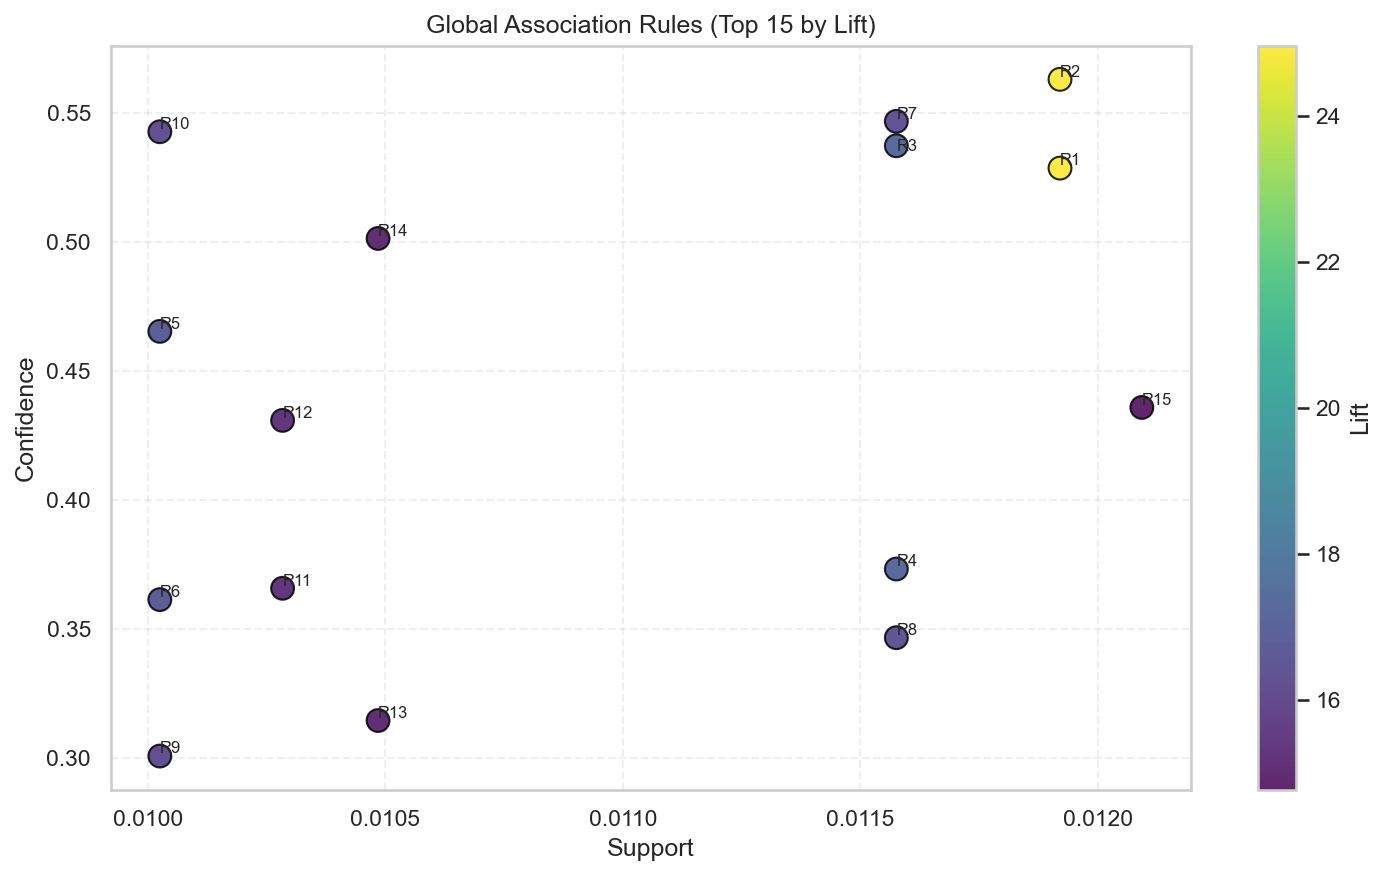

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\top10_itemsets_global.png


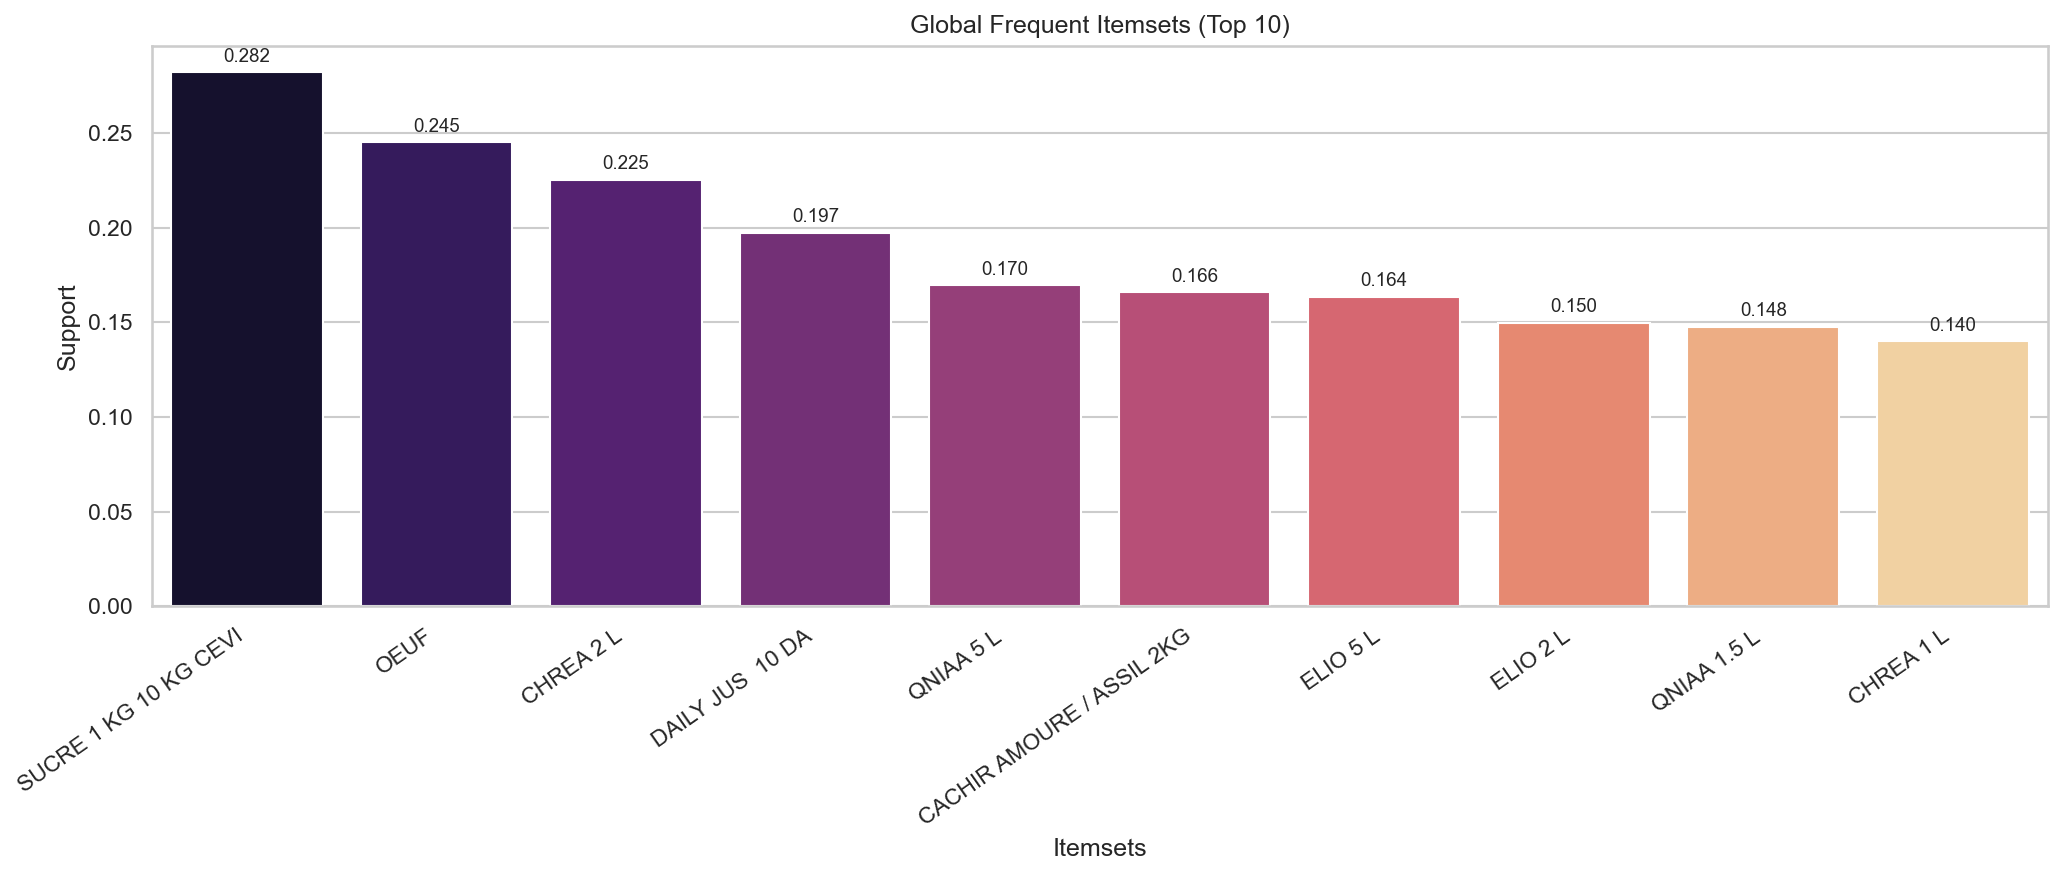

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\rules_scatter_cluster_0.0.png


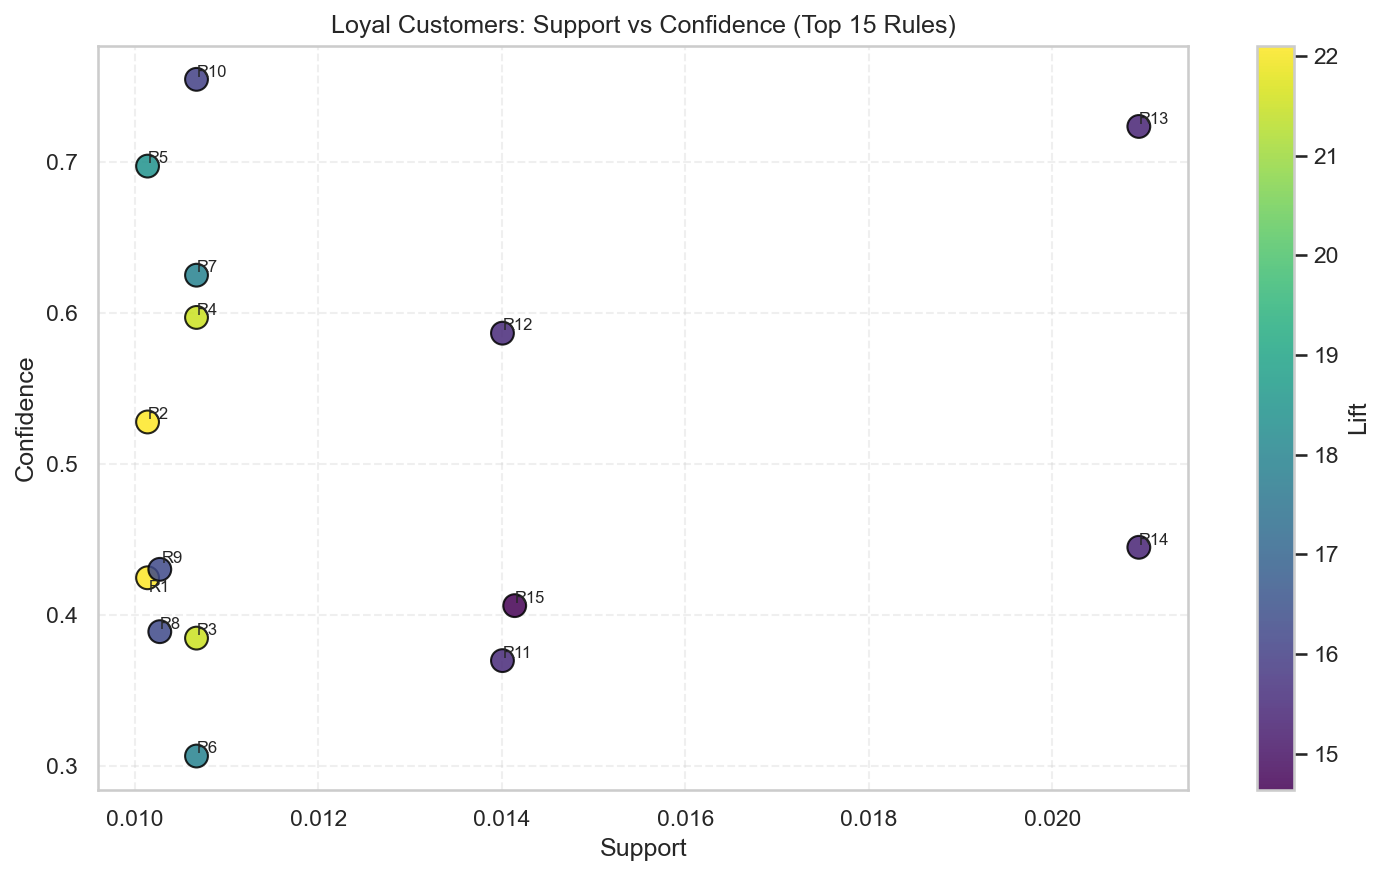

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\top10_itemsets_cluster_0.0.png


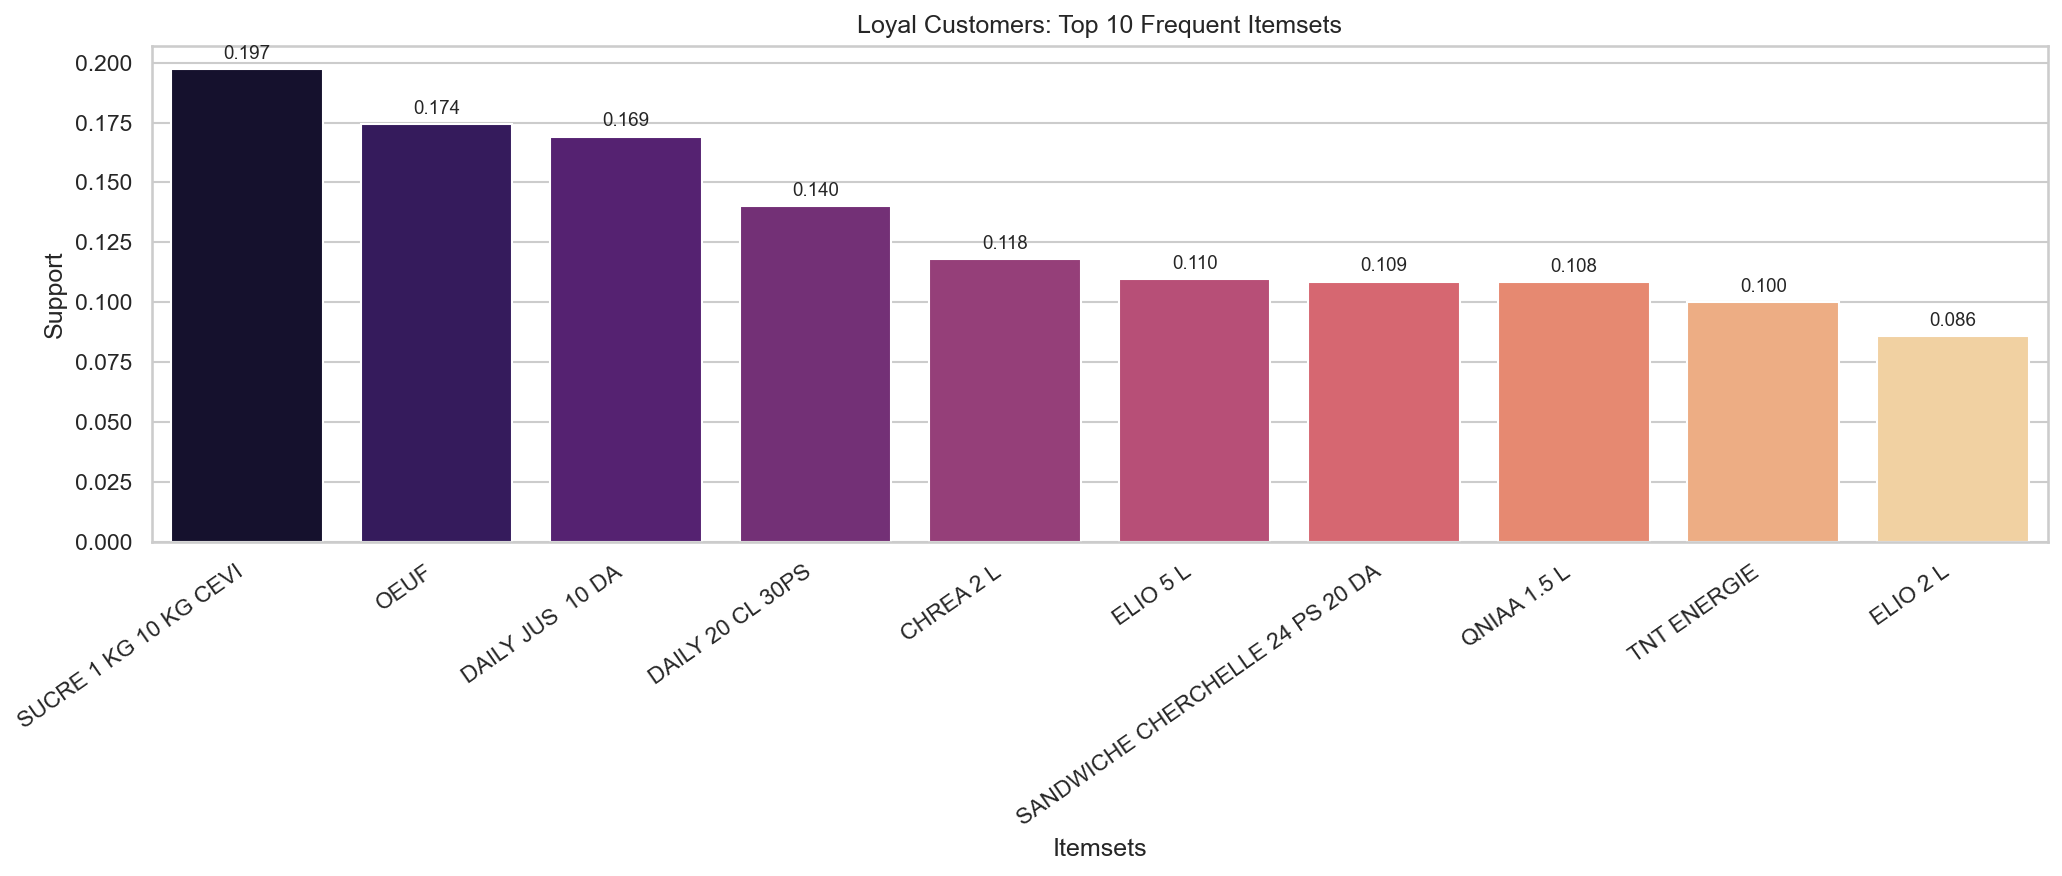

3 [ 0.51503099 -0.8888505 ]
6 [-0.18872071 -0.28102921]
1 [-0.74922411 -0.38932082]
5 [ 0.08130367 -0.84238627]
Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\rules_scatter_cluster_1.0.png


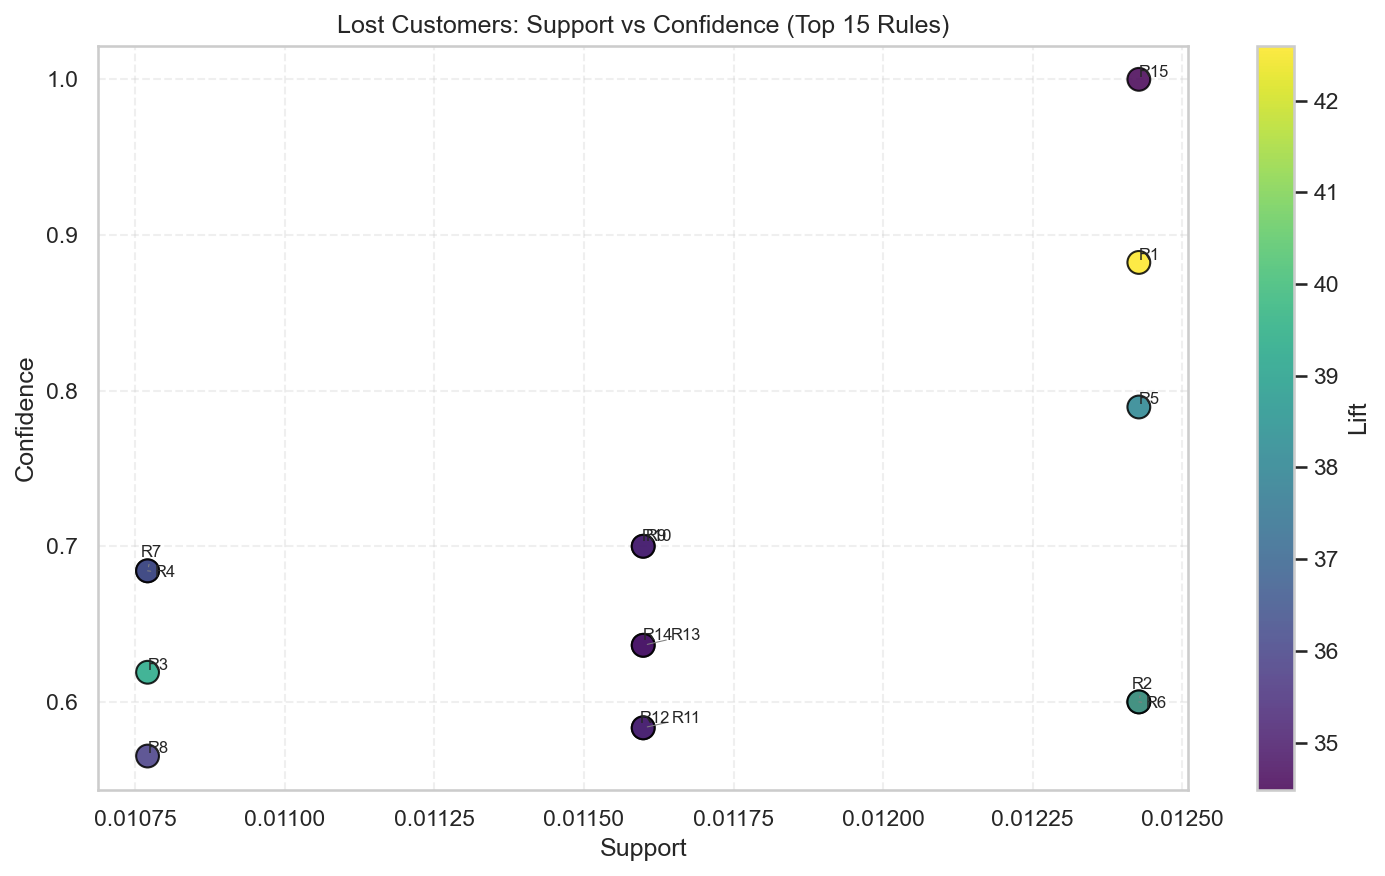

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\top10_itemsets_cluster_1.0.png


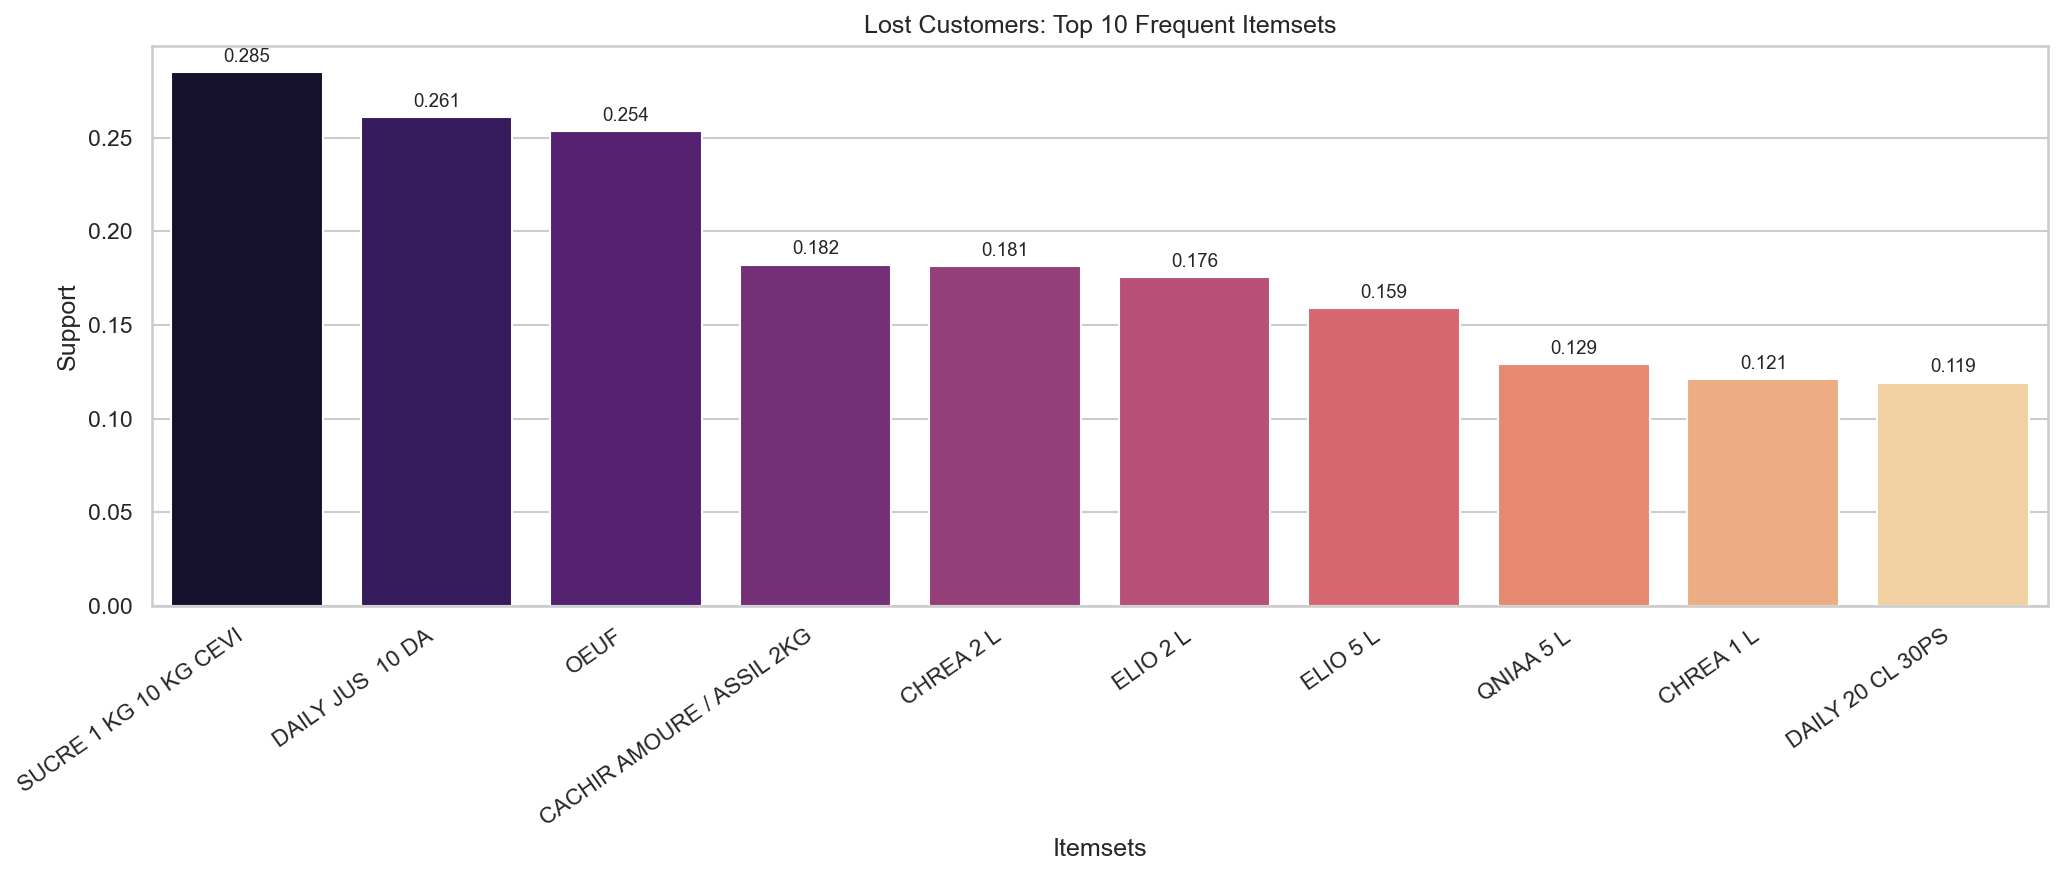

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\rules_scatter_cluster_2.0.png


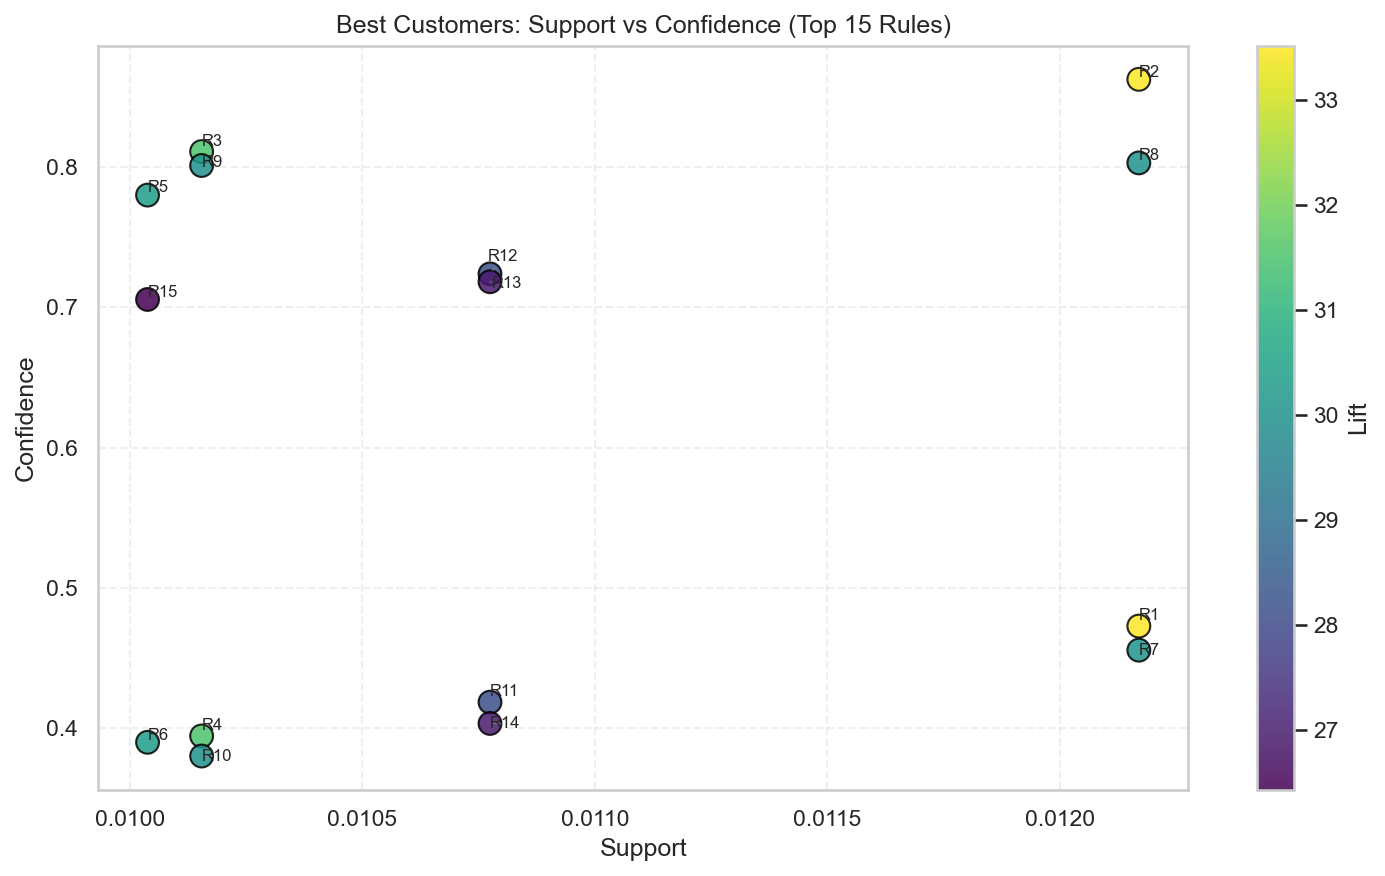

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\top10_itemsets_cluster_2.0.png


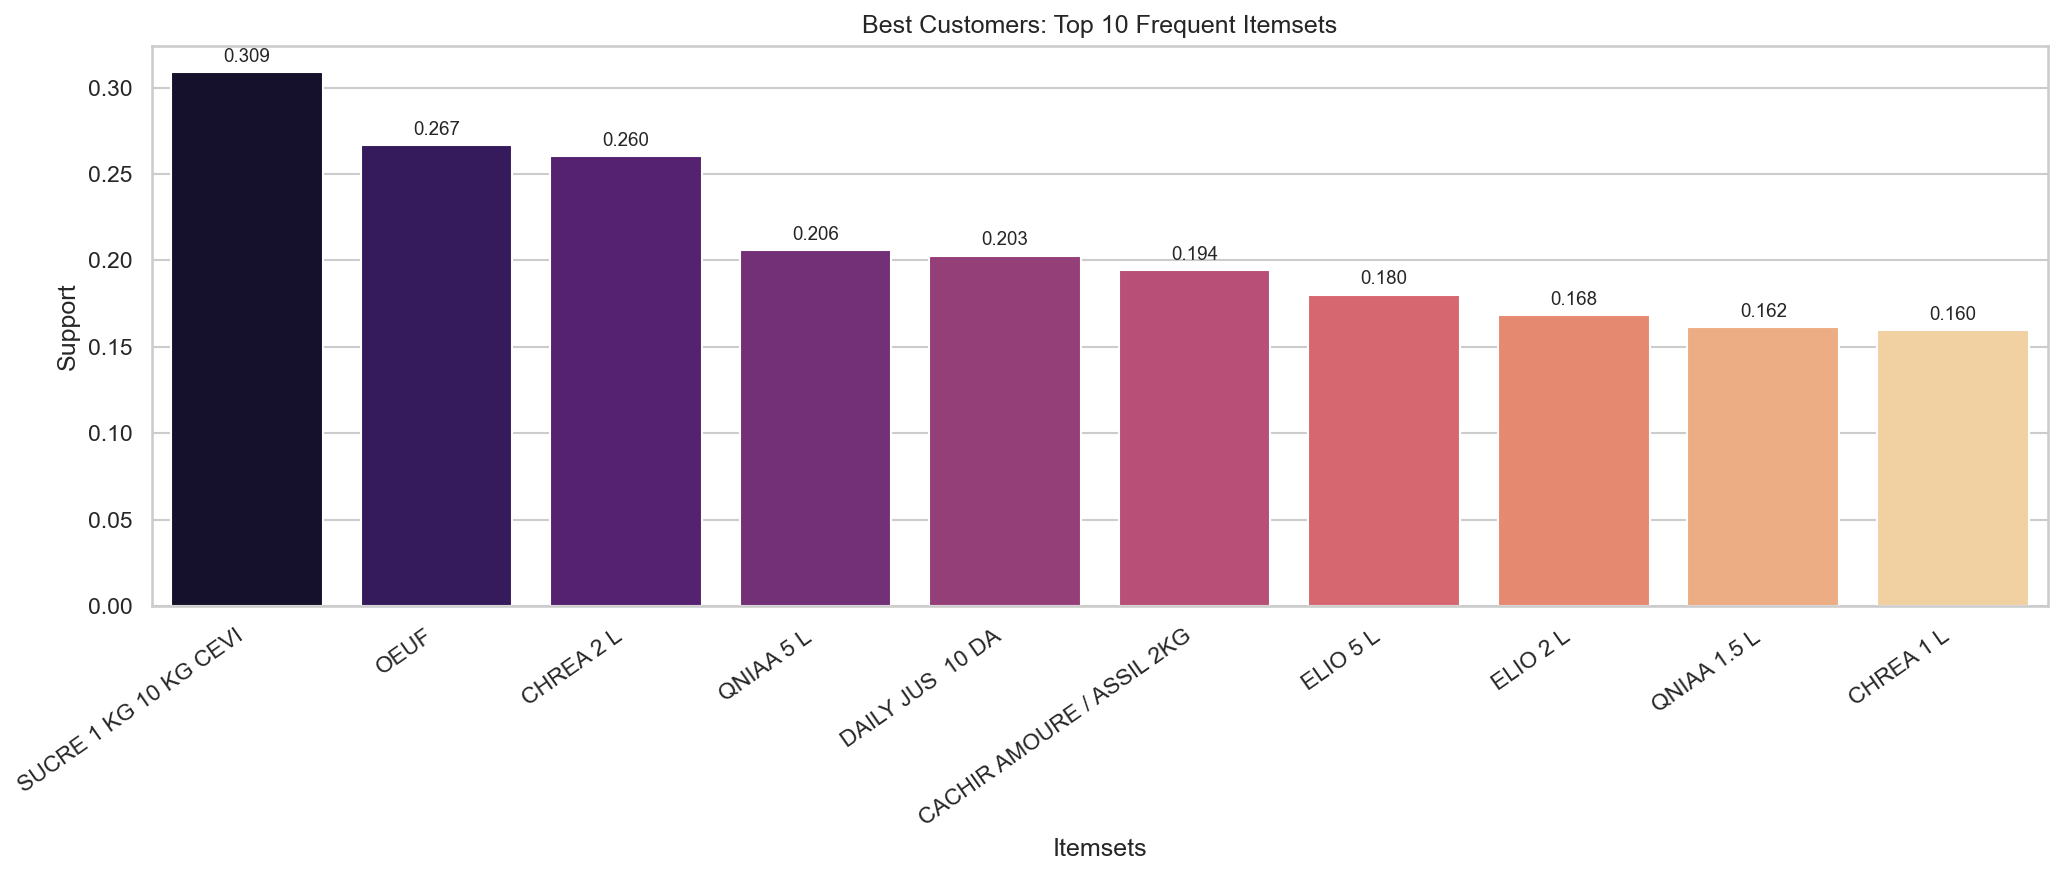

2 [ 0.3023381  -0.68240901]
4 [-0.43188735  0.16471626]
0 [-0.70068413 -0.90185985]
1 [0.16788237 0.38987053]
3 [-0.11928967  0.30505924]
5 [ 0.52828363 -0.49335152]
6 [0.60507777 0.0889068 ]
7 [-0.03986541 -0.94062949]
12 [-0.60852236 -0.38282204]
14 [ 0.36166132 -0.76685824]
9 [0.18828453 0.11054597]
11 [-0.22570786 -0.30057473]
13 [ 0.66340856 -0.98032248]
Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\rules_scatter_cluster_3.0.png


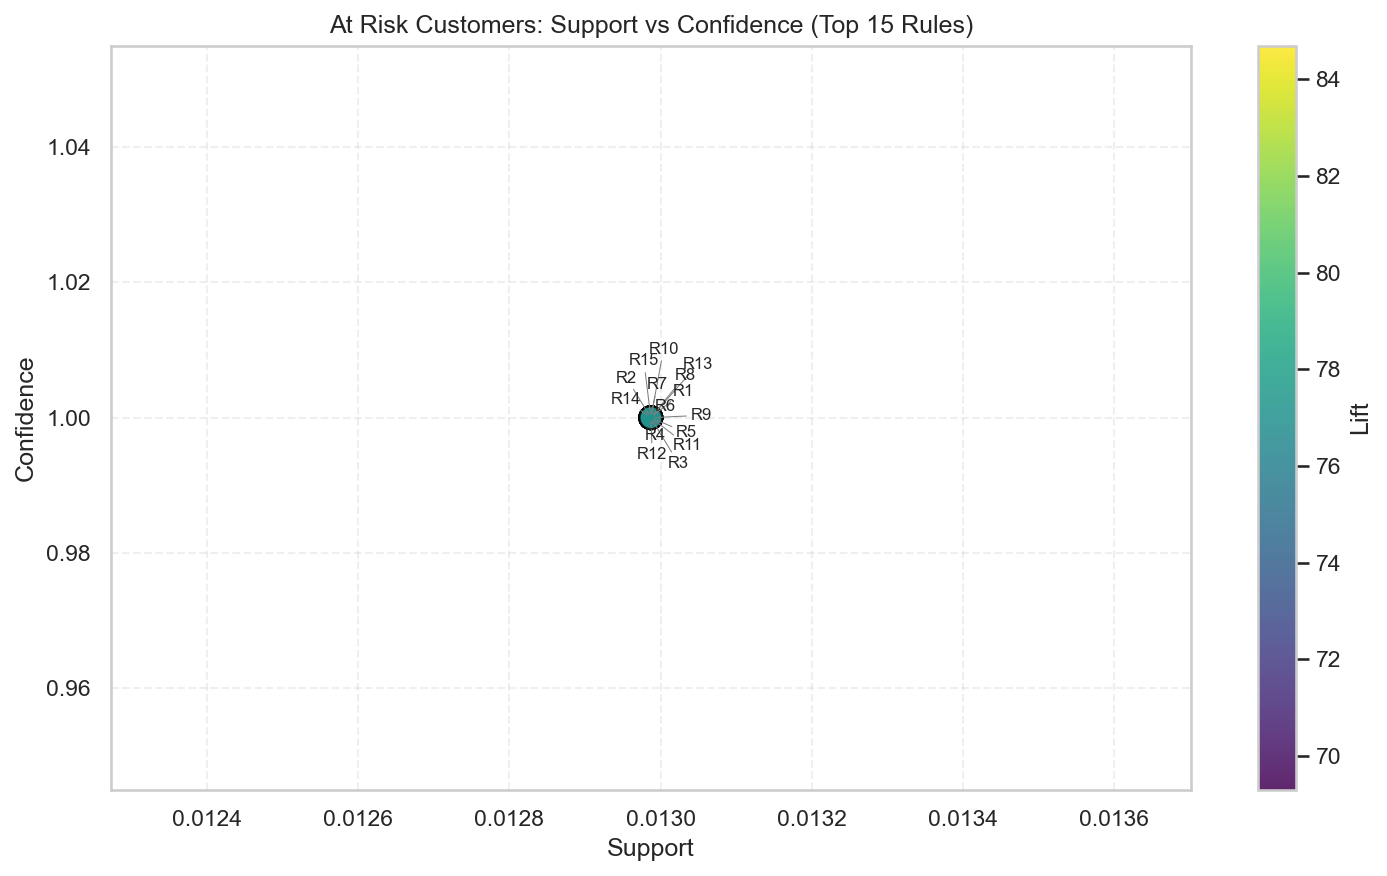

Saved: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures\top10_itemsets_cluster_3.0.png


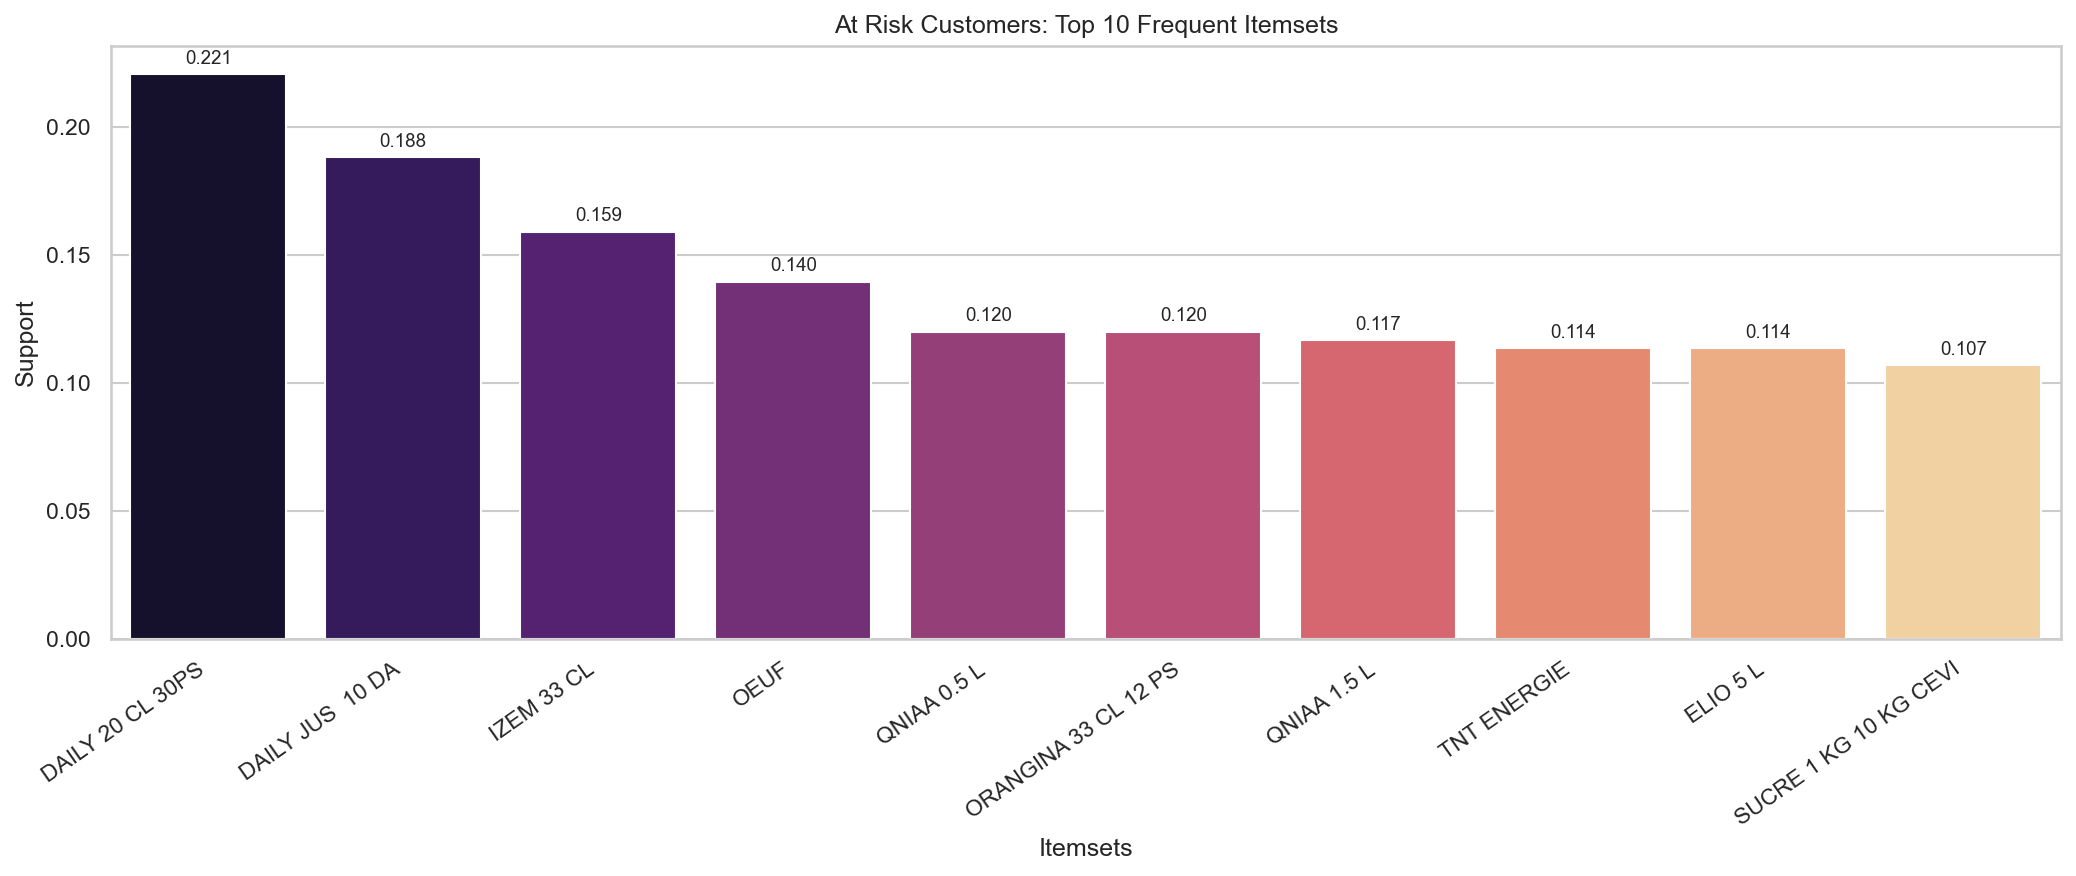

In [21]:
from adjustText import adjust_text

def plot_rules_scatter(rules_df, title, save_path=None, top_n=15):
    if rules_df.empty:
        print(f"No rules to plot for {title}")
        return
    top = rules_df.sort_values("lift", ascending=False).head(top_n).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    sc = ax.scatter(
        top["support"], top["confidence"], c=top["lift"],
        cmap="viridis", s=120, edgecolor="black", alpha=0.85
    )
    texts = []
    for i, row in top.iterrows():
        texts.append(ax.text(row["support"], row["confidence"], f"R{i+1}", fontsize=8))
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Lift")
    ax.set_xlabel("Support")
    ax.set_ylabel("Confidence")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print("Saved:", save_path)
    plt.show()

def plot_top_itemsets(itemsets_df, title, save_path=None, top_n=10):
    if itemsets_df.empty:
        print(f"No itemsets to plot for {title}")
        return
    top = itemsets_df.sort_values("support", ascending=False).head(top_n).copy()
    top["label"] = top["itemsets"].apply(lambda s: ", ".join(sorted(map(str, s))))
    plt.figure(figsize=(14, 6), dpi=150)
    ax = sns.barplot(data=top, x="label", y="support", hue="label", dodge=False, palette="magma", legend=False)
    for patch in ax.patches:
        h = patch.get_height()
        ax.annotate(f"{h:.3f}", (patch.get_x() + patch.get_width()/2, h), ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")
    plt.title(title)
    plt.xlabel("Itemsets")
    plt.ylabel("Support")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print("Saved:", save_path)
    plt.show()

plot_rules_scatter(rules_global, "Global Association Rules (Top 15 by Lift)", fig_dir / "rules_scatter_global.png")
plot_top_itemsets(itemsets_global, "Global Frequent Itemsets (Top 10)", fig_dir / "top10_itemsets_global.png")

for cluster_id, payload in cluster_results.items():
    plot_rules_scatter(
        payload["rules"],
        f"{cluster_label(cluster_id)}: Support vs Confidence (Top 15 Rules)",
        fig_dir / f"rules_scatter_cluster_{cluster_id}.png",
    )
    plot_top_itemsets(
        payload["itemsets"],
        f"{cluster_label(cluster_id)}: Top 10 Frequent Itemsets",
        fig_dir / f"top10_itemsets_cluster_{cluster_id}.png",
    )

## Step 7 - Comparison Table

In [22]:
summary_df = pd.DataFrame(summary_rows)
print(summary_df)
summary_df.to_csv(model_dir / "rules_summary.csv", index=False, encoding="utf-8-sig")

   cluster  nb_baskets  nb_rules   avg_lift  avg_confidence  avg_support
0      0.0        7497       302   5.445580        0.468930     0.015676
1      1.0        1207     10387   7.276238        0.545832     0.014273
2      2.0       25801     12126   4.453606        0.496563     0.014356
3      3.0         308      8125  30.776604        0.771950     0.013928


## Step 8 - Interpretation (English)

In [23]:
for cluster_id, payload in cluster_results.items():
    rules_c = payload["rules"]
    print()
    print(f"Cluster {cluster_id}")

    if rules_c.empty:
        print("Top 5 rules: no rules after filtering.")
        print("Interpretation: no stable association pattern under current thresholds.")
        continue

    top5 = rules_c[["antecedents", "consequents", "support", "confidence", "lift"]].head(5)
    print("Top 5 rules by lift:")
    print(top5.to_string(index=False))

    items = []
    for _, r in top5.iterrows():
        items.extend(list(r["antecedents"]))
        items.extend(list(r["consequents"]))

    items = [str(x).strip() for x in items if str(x).strip()]
    top_products = pd.Series(items).value_counts().head(4).index.tolist() if items else []

    if top_products:
        print("Interpretation: this segment is mainly driven by associations around:", ", ".join(top_products))
    else:
        print("Interpretation: mixed purchase behavior with no dominant product family.")



Cluster 0.0
Top 5 rules by lift:
                                     antecedents                                  consequents  support  confidence      lift
                  frozenset({RAMY 33 CL  12 PS}) frozenset({IFRI JUS 33CL, DAILY 20 CL 30PS}) 0.010137    0.424581 22.104749
    frozenset({IFRI JUS 33CL, DAILY 20 CL 30PS})               frozenset({RAMY 33 CL  12 PS}) 0.010137    0.527778 22.104749
                        frozenset({SOMAM JNINA})         frozenset({SOMAM FORT, SOMAM BNINA}) 0.010671    0.384615 21.518370
            frozenset({SOMAM FORT, SOMAM BNINA})                     frozenset({SOMAM JNINA}) 0.010671    0.597015 21.518370
frozenset({RAMY 33 CL  12 PS, DAILY 20 CL 30PS})                   frozenset({IFRI JUS 33CL}) 0.010137    0.697248 18.405866
Interpretation: this segment is mainly driven by associations around: RAMY 33 CL  12 PS, IFRI JUS 33CL, DAILY 20 CL 30PS, SOMAM JNINA

Cluster 1.0
Top 5 rules by lift:
                                                

## Final Check

In [24]:
print("Figures path:", fig_dir)
print("Models path:", model_dir)
print(df_merged.groupby(["cluster"])["code_client"].count().reset_index())

Figures path: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\figures
Models path: C:\Users\H-Info\OneDrive\Desktop\graduation_project\2425produits analysis\outputs\models
   cluster  code_client
0      0.0        57071
1      1.0        13533
2      2.0       326753
3      3.0         2438
